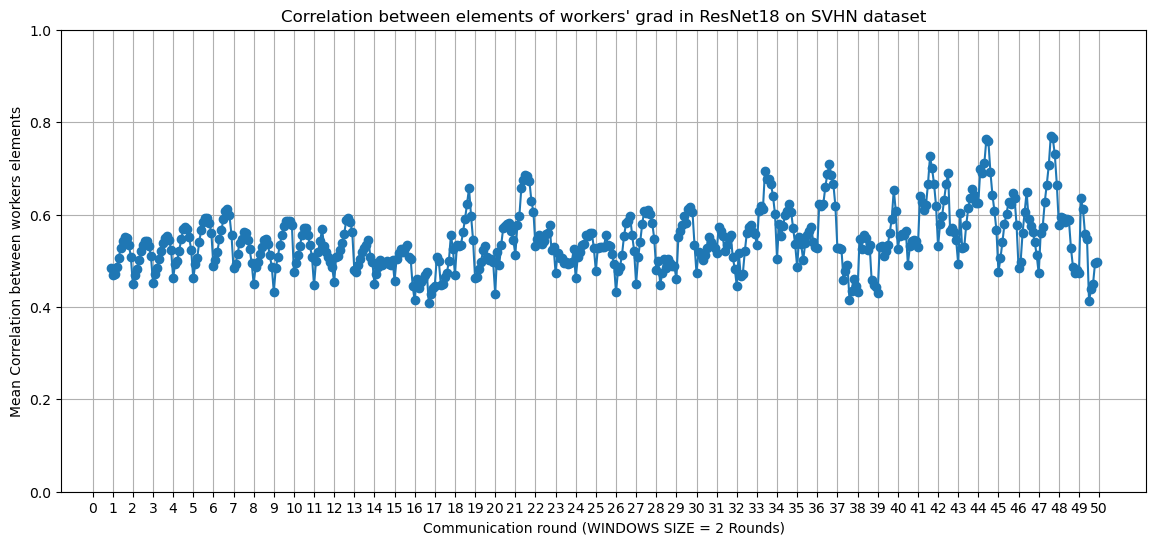

In [9]:
import pickle
import gzip
from matplotlib import pyplot as plt
import numpy as np

epoch_count=10
batch_count=np.ceil(73200/13000/2)
min_window_size=10*2

file_name = f'corr_res_{1}.pkl.gz'
with gzip.open(file_name, 'rb') as f:
    temp = pickle.load(f)
    y, x, nan_ratios = list(zip(*temp))

x = np.array(x)
y = np.array(y)

plt.figure(figsize=(14, 6))
plt.plot(x, y, marker='o')
plt.xticks(list(range(int(np.floor(x.min())), int(np.ceil(x.max())+1))))
plt.xlabel('Communication round (WINDOWS SIZE = 2 Rounds)')
plt.ylabel('Mean Correlation between workers elements')
plt.title('Correlation between elements of workers\' grad in ResNet18 on SVHN dataset')
plt.ylim(0, 1)
plt.grid()
plt.show()

In [3]:
# import numpy as np
# import os
# import pickle
# import gzip
# from matplotlib import pyplot as plt
#
# epoch_count = 10
# batch_count = 3
#
# loaded_files = []
# x = []
# for file_name in os.listdir('accum_grads/'):
#     if not file_name.endswith('.pkl.gz'):
#         continue
#     with gzip.open(os.path.join('accum_grads/', file_name), 'rb') as f:
#         res = pickle.load(f)
#         loaded_files.append([None, res])
#     temp = {
#         "round_num": int(file_name.split(',')[0].split('_')[-1]),
#         "epoch_num": int(file_name.split(',')[1].split('_')[1]),
#         "batch_num": int(file_name.split(',')[2].split('_')[1].split('.')[0])
#     }
#     temp = temp['round_num'] + (temp['epoch_num'] + temp['batch_num'] / batch_count) / epoch_count
#     x.append(temp)
#     loaded_files[-1][0] = temp
#
# loaded_files.sort(key=lambda x: x[0])
# y = np.array([x[1] for x in loaded_files])
# x.sort()
# temp = [*np.isnan(y)]
# non_nan_idx = temp[0]
# ratios = [len(non_nan_idx) / len(y)]
# for i in range(1, len(temp)):
#     non_nan_idx = np.logical_or(non_nan_idx, temp[i])
#     ratios += [len(non_nan_idx) / len(y)]
# y = y.T[~non_nan_idx]
#
# y = np.mean(y, axis=0)
# print(y.shape, ratios[0], ratios[-1])
# plt.figure(figsize=(14, 6))
# plt.plot(x, y, )
# plt.xticks([0, 1, 2, 3, 4, ])
# plt.xlabel('Communication round (+epoch/10 + batch/3/10)')
# plt.ylabel('Correlation between workers')
# plt.title('Correlation between workers\' gradients in ResNet18 on SVHN dataset')
# plt.grid()
# plt.show()